<a href="https://colab.research.google.com/github/alfanfhd/Pembelajaran-Mesin-2026/blob/main/TG6_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Praktikum1

In [1]:
# import package
import numpy as np
import pandas as pd

In [2]:
# baca data dari file CSV
data = pd.read_csv('dataset.csv')

In [3]:
# melihat beberapa data awal
data.head()

# mengecek ukuran data
data.shape

# informasi tentang data
data.info()

# deskripsi data
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [4]:
# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


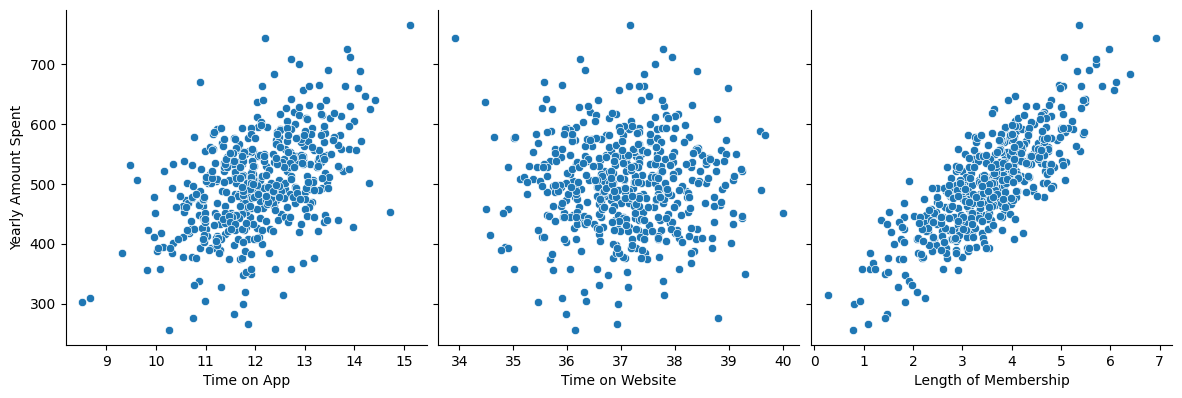

In [5]:
# visualisasi data dengan pairplot
sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars='Yearly Amount Spent', size=4, aspect=1, kind='scatter')
plt.show()

Kolom numerik: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']


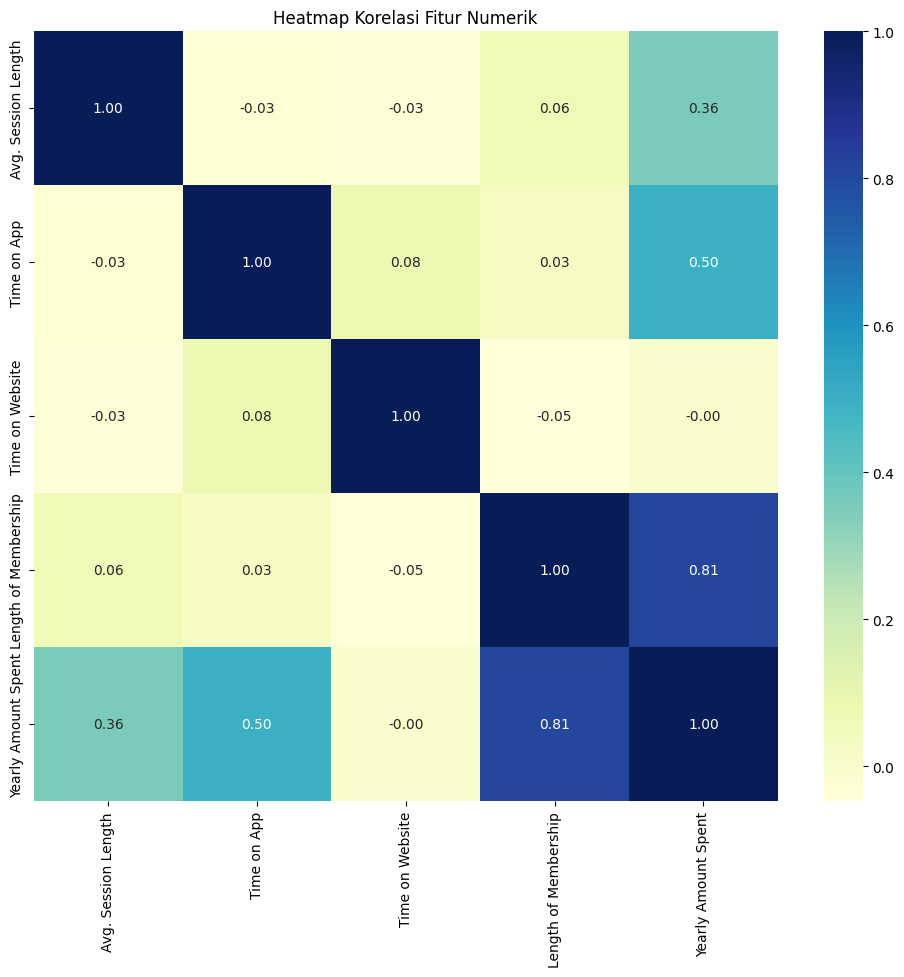

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pastikan data sudah di-load sebelumnya
# df = pd.read_csv('...')  # sesuaikan

# Pilih hanya kolom numerik
numeric_data = data.select_dtypes(include=[np.number])

# Cek kolom apa saja yang numerik
print("Kolom numerik:", numeric_data.columns.tolist())

# Buat heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_data.corr(), cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

In [8]:
# Membuat variabel bebas X dan Y, contoh pengambilan dari analisis korelasi sebelumnya
X = data['Length of Membership']
y = data['Yearly Amount Spent']

In [9]:
# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [10]:
# Training model
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()

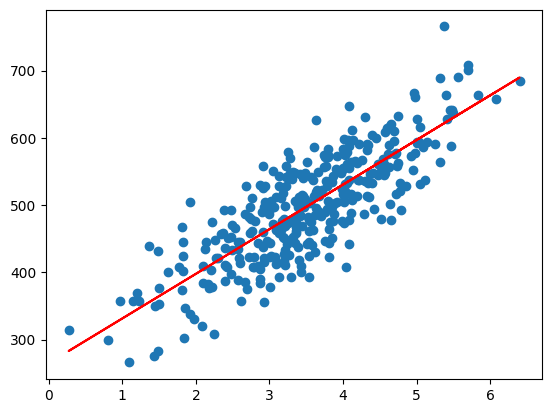

In [11]:
# Visualisasi garis regresi
plt.scatter(X_train, y_train)
plt.plot(X_train, 265.2483 + 66.3015*X_train, 'r')
plt.show()

In [12]:
# Prediksi nilai y_value dari data x yang telah dilatih
y_train_pred = lr.predict(X_train_sm)

# Menghitung residual
res = (y_train - y_train_pred)

/tmp/ipykernel_1175/594495671.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res, bins=15)


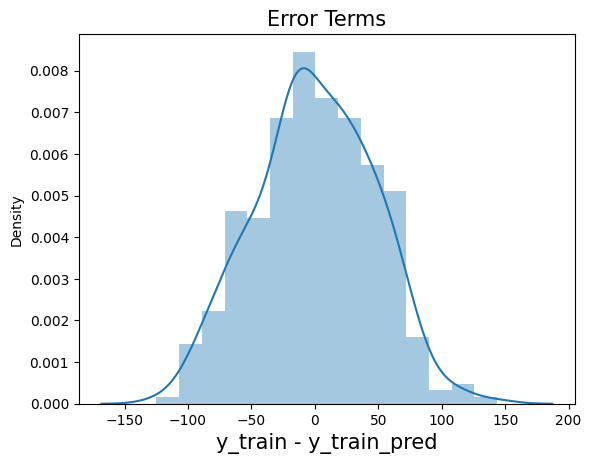

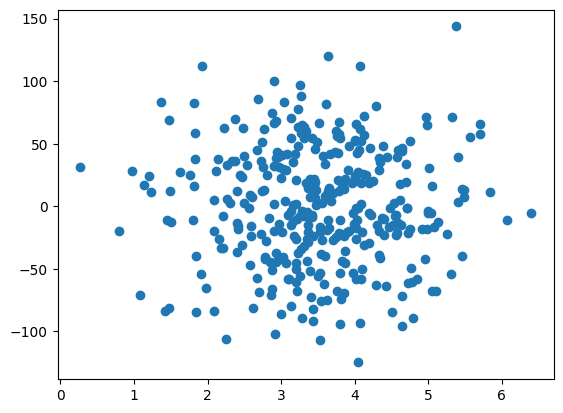

In [13]:
# Histogram residual
fig = plt.figure()
sns.distplot(res, bins=15)
plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# Scatter plot residual
plt.scatter(X_train, res)
plt.show()

In [14]:
# Prediksi pada data uji
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

In [15]:
# Hitung nilai R-squared
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_test_pred)

In [ ]:
# Visualisasi data uji dan hasil prediksi
plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, 'r')
plt.show()

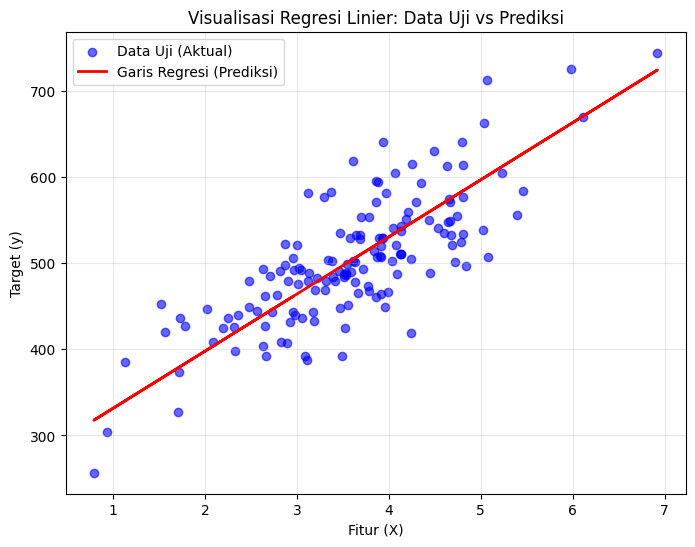

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot data uji (titik-titik)
plt.scatter(X_test, y_test, color='blue', label='Data Uji (Aktual)', alpha=0.6)

# Plot garis regresi (prediksi)
plt.plot(X_test, y_test_pred, color='red', linewidth=2, label='Garis Regresi (Prediksi)')

plt.xlabel('Fitur (X)')
plt.ylabel('Target (y)')
plt.title('Visualisasi Regresi Linier: Data Uji vs Prediksi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Praktikum2

In [17]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
# Mengimpor dataset (Pastikan Anda memiliki file CSV 'Posisi_gaji.csv' dalam direktori yang sama)
dataset = pd.read_csv('Posisi_gaji.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values  # Ubah menjadi satu kolom saja

In [19]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))

In [20]:
# Fitting SVR ke dataset
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

/tmp/ipykernel_1175/1841224750.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


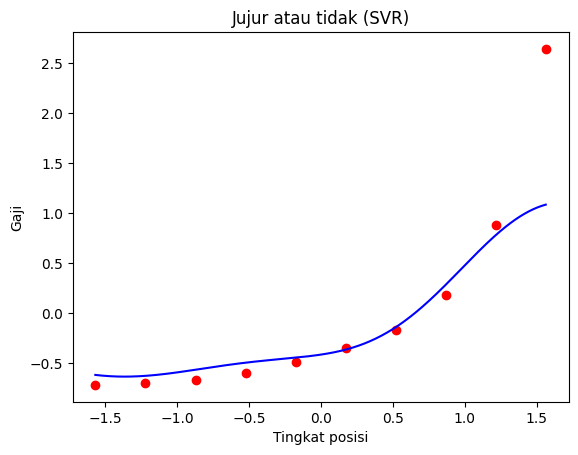

In [21]:
# Visualisasi hasil SVR (resolusi tinggi dan kurva yang lebih halus)
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Jujur atau tidak (SVR)')
plt.xlabel('Tingkat posisi')
plt.ylabel('Gaji')
plt.show()

In [22]:
# Prediksi hasil
# Buat array 2D yang berisi tingkat posisi yang akan diprediksi
tingkat_posisi_prediksi = np.array([[6.5]])
# Penskalaan fitur untuk data yang akan diprediksi
tingkat_posisi_prediksi = sc_X.transform(tingkat_posisi_prediksi)
# Melakukan prediksi menggunakan model SVR
gaji_prediksi = regressor.predict(tingkat_posisi_prediksi)
# Kembalikan hasil prediksi ke skala aslinya
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi.reshape(-1, 1))

In [23]:
# Menampilkan hasil prediksi
print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [170370.0204065]


In [24]:
# Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y
y_pred = regressor.predict(X)

# Menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.22299274095734414
MSE: 0.24839989293792014
RMSE: 0.4983973243687411
R-squared: 0.7516001070620798


# Tugas Praktikum

INFORMASI DATASET
Jumlah baris: 1,338
Jumlah kolom: 7

5 baris pertama:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Tipe data:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Statistik deskriptif:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
5

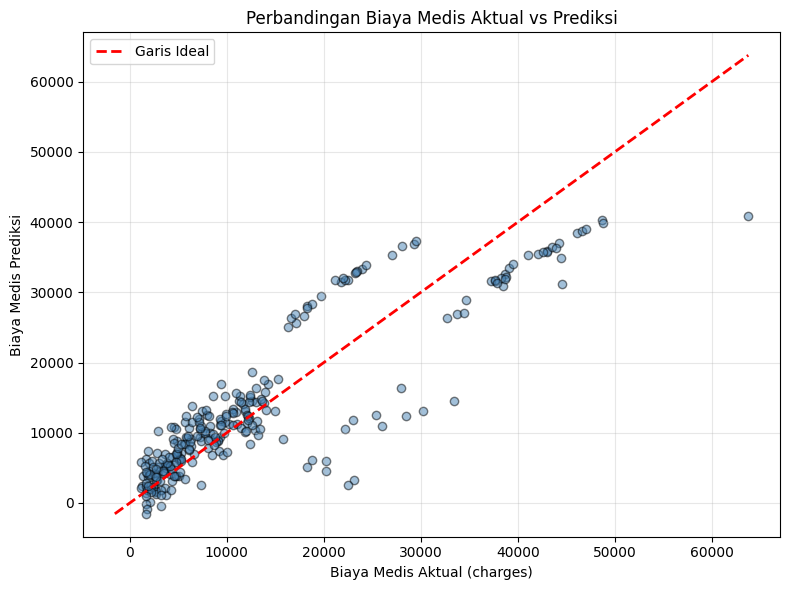

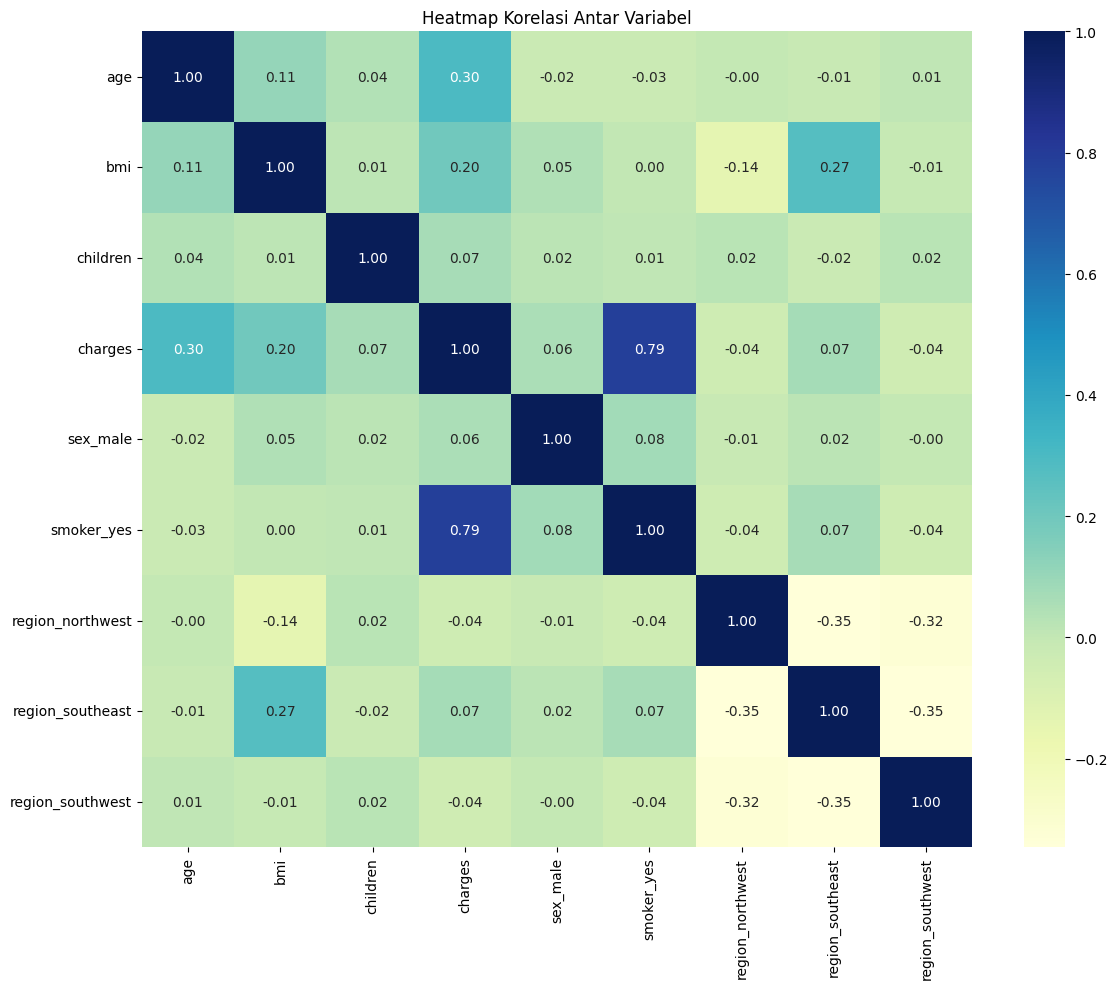

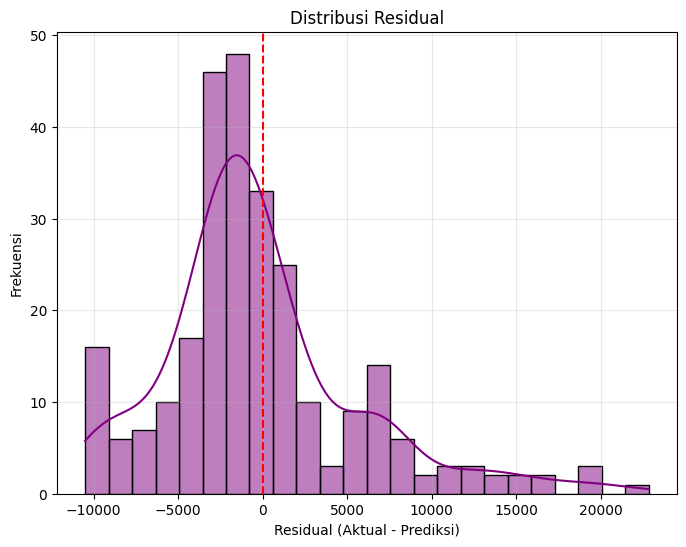

In [25]:
# ==========================================
# 0. IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================
# 1. LOAD DATASET & EKSPLORASI
# ==========================================
df = pd.read_csv('/content/insurance.csv')

print("="*60)
print("INFORMASI DATASET")
print("="*60)
print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n5 baris pertama:")
print(df.head())
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik deskriptif:")
print(df.describe())

# Cek missing values
print("\nMissing values:")
print(df.isnull().sum())

# ==========================================
# 2. IDENTIFIKASI VARIABEL
# ==========================================
# Variabel Target (y): charges (biaya medis)
# Variabel Bebas (X): age, sex, bmi, children, smoker, region

# Encoding kolom kategorikal
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print("\n" + "="*60)
print("KOLOM SETELAH ENCODING")
print("="*60)
print(df_encoded.columns.tolist())

# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

# ==========================================
# 3. SPLIT DATA (TRAIN & TEST)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nData train: {X_train.shape[0]} baris")
print(f"Data test : {X_test.shape[0]} baris")

# ==========================================
# 4. FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. BUAT & LATIH MODEL
# ==========================================
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediksi
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Lihat koefisien
print("\n" + "="*60)
print("KOEFISIEN MODEL")
print("="*60)
koef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)
print(koef_df)
print(f"\nIntercept: {model.intercept_:.4f}")

# ==========================================
# 6. EVALUASI MODEL
# ==========================================
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print("\n" + "="*60)
print("HASIL EVALUASI MODEL")
print("="*60)
print(f"R² (Train) : {r2_train:.4f}")
print(f"R² (Test)  : {r2_test:.4f}")
print(f"MSE        : {mse:,.2f}")
print(f"RMSE       : {rmse:,.2f}")
print(f"MAE        : {mae:,.2f}")

# ==========================================
# 7. VISUALISASI HASIL
# ==========================================
# Plot 1: Aktual vs Prediksi
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.5, edgecolor='k')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Garis Ideal')
plt.xlabel('Biaya Medis Aktual (charges)')
plt.ylabel('Biaya Medis Prediksi')
plt.title('Perbandingan Biaya Medis Aktual vs Prediksi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Heatmap Korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), cmap='YlGnBu', annot=True, fmt='.2f')
plt.title('Heatmap Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

# Plot 3: Distribusi Residual
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Residual')
plt.grid(True, alpha=0.3)
plt.show()